# Detección de rostros con Haar

En este cuaderno vas a usar un detector clásico de OpenCV para ubicar rostros en una imagen. La idea no es solo correr una función, sino entender qué problema intenta resolver, cómo lo resuelve y por qué todavía sigue siendo una referencia útil aunque hoy existan métodos más modernos.


## Objetivo

Aplicar un detector de rostros con cascadas de Haar y entender qué significa realmente detectar una cara con este tipo de método.

## Resultados de aprendizaje

Al finalizar este cuaderno, vas a poder:

- explicar de manera general cómo funciona la detección con Haar;
- cargar una cascada provista por OpenCV;
- aplicar `detectMultiScale()` sobre una imagen en grises;
- interpretar el efecto de parámetros como `scaleFactor` y `minNeighbors`;
- reconocer límites del enfoque clásico frente a escenas más complejas.

## Relación con la secuencia

Este cuaderno aparece después de haber trabajado coordenadas, anotación y detección de regiones. La novedad es que ahora ya no marcamos una región manualmente: usamos un detector previamente entrenado.


## Marco conceptual

La detección de rostros es un caso específico de detección de objetos. El objetivo no es reconocer la identidad de una persona, sino encontrar y localizar regiones de la imagen que se parezcan a un rostro humano.

Hoy el estado del arte está dominado por redes profundas. Sin embargo, las cascadas de Haar siguen siendo una herramienta muy valiosa para aprender varios conceptos importantes:

- la idea de recorrer una imagen con múltiples ventanas;
- el uso de rasgos simples para describir patrones visuales;
- la lógica de una cascada que descarta rápido regiones poco prometedoras;
- la relación entre velocidad, costo computacional y precisión.

Si querés una intuición rápida, podés pensar el método así: la imagen se recorre con muchas ventanas posibles y, en cada una, el detector pregunta si el patrón tonal se parece o no al de un rostro.


## Videos para observar antes de programar

Antes de pasar al código, mirá estos dos recursos. La idea es que te ayuden a construir una intuición visual del método.

Mientras los mirás, conviene prestar atención a estas preguntas:

- ¿qué significa recorrer la imagen con ventanas de distintos tamaños?
- ¿por qué conviene descartar rápido regiones que claramente no contienen un rostro?
- ¿qué ventaja tiene una cascada frente a evaluar todas las regiones con el mismo costo?


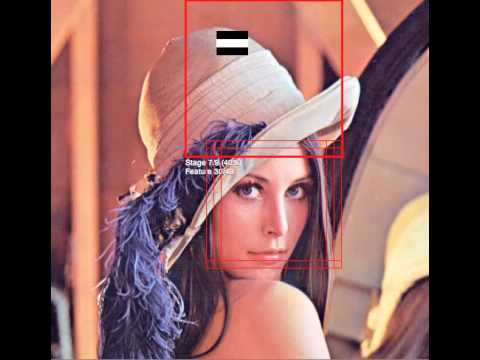

In [1]:
# Importamos una herramienta para embeber videos de YouTube dentro del cuaderno.
from IPython.display import YouTubeVideo

# Video clásico sobre la lógica de Viola-Jones y cascadas de Haar.
YouTubeVideo('hPCTwxF0qf4', width=800, height=450)


Este primer video sirve para ubicar el método dentro de la historia de la visión por computadora y para entender la idea general de la cascada.


In [ ]:
# Segundo video para reforzar la intuición visual del procedimiento.
YouTubeVideo('iht5zlGV_X4', width=800, height=450)


Después de ver ambos recursos, la idea central debería quedar más clara: el detector no entiende el rostro como una persona, sino como un patrón visual que se parece a ciertos ejemplos aprendidos previamente.


## Módulos que vamos a usar

- `pathlib.Path`: para construir la ruta de la imagen de trabajo.
- `cv2`: para cargar la cascada Haar, convertir a grises y detectar rostros.
- `matplotlib.pyplot`: para visualizar la imagen original y los resultados.
- `cv2.data.haarcascades`: para acceder al archivo XML del detector provisto por OpenCV.


In [2]:
# Importamos Path para trabajar con rutas de archivos.
from pathlib import Path

# Importamos OpenCV para cargar la cascada y detectar rostros.
import cv2

# Importamos Matplotlib para visualizar las imágenes.
import matplotlib.pyplot as plt


## 1. Imagen de trabajo y preparación del detector

Vamos a usar una imagen conocida y un detector clásico que ya viene con OpenCV. Antes de detectar, también convertimos la imagen a escala de grises, porque el algoritmo de Haar trabaja sobre intensidades y no sobre color.

En el resultado esperable deberías ver la imagen original y su versión en grises.


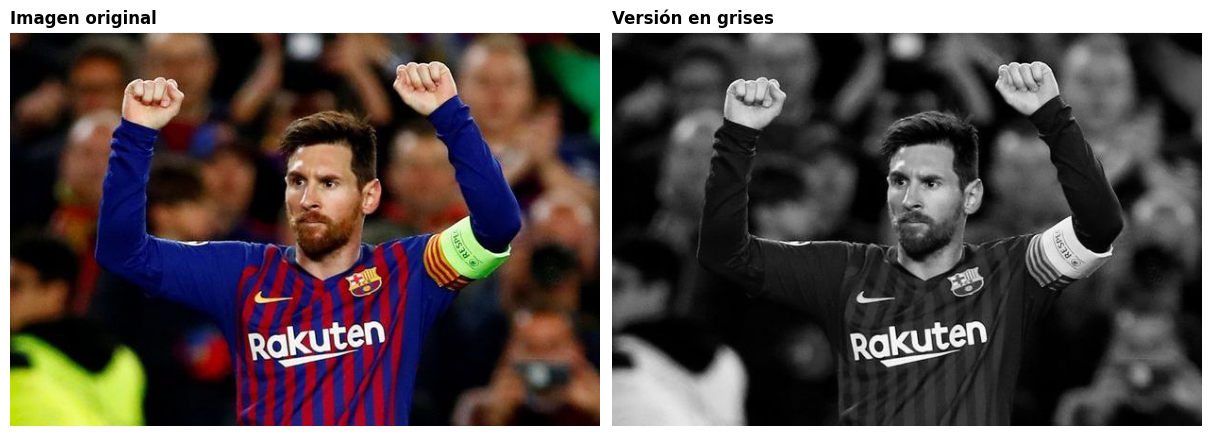

In [3]:
# Construimos la ruta de la imagen principal.
ruta_imagen = Path('Imagenes') / 'messi.jpg'

# Leemos la imagen en color.
imagen_bgr = cv2.imread(str(ruta_imagen), cv2.IMREAD_COLOR)
if imagen_bgr is None:
    raise FileNotFoundError(f'No se pudo leer la imagen: {ruta_imagen}')

# Convertimos la imagen a RGB para visualizarla correctamente con Matplotlib.
imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

# Convertimos la imagen a escala de grises porque la cascada Haar trabaja sobre intensidades.
imagen_gris = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2GRAY)

# Accedemos al archivo XML de la cascada de rostros frontales incluido en OpenCV.
ruta_cascada = Path(cv2.data.haarcascades) / 'haarcascade_frontalface_default.xml'
detector_rostros = cv2.CascadeClassifier(str(ruta_cascada))
if detector_rostros.empty():
    raise FileNotFoundError(f'No se pudo cargar la cascada: {ruta_cascada}')

# Mostramos la imagen original y la versión en grises.
fig, ejes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
ejes[0].imshow(imagen_rgb)
ejes[0].set_title('Imagen original', fontweight='bold', loc='left')
ejes[0].axis('off')
ejes[1].imshow(imagen_gris, cmap='gray')
ejes[1].set_title('Versión en grises', fontweight='bold', loc='left')
ejes[1].axis('off')
plt.show()


La conversión a grises simplifica la representación: el detector ya no analiza color, sino patrones de intensidad. Eso reduce la complejidad del problema y vuelve más eficiente el recorrido de ventanas.


## 2. Aplicar el detector con una configuración inicial

Ahora usamos `detectMultiScale()`. Esta función recorre la imagen buscando regiones que se parezcan a la estructura aprendida por la cascada.

Los parámetros iniciales que vamos a usar son:

- `scaleFactor=1.1`: controla cuánto cambia el tamaño de la ventana en cada paso;
- `minNeighbors=5`: exige cierta consistencia entre detecciones cercanas;
- `minSize=(40, 40)`: evita considerar regiones demasiado pequeñas.

En el resultado esperable deberías ver uno o más rectángulos sobre la imagen.


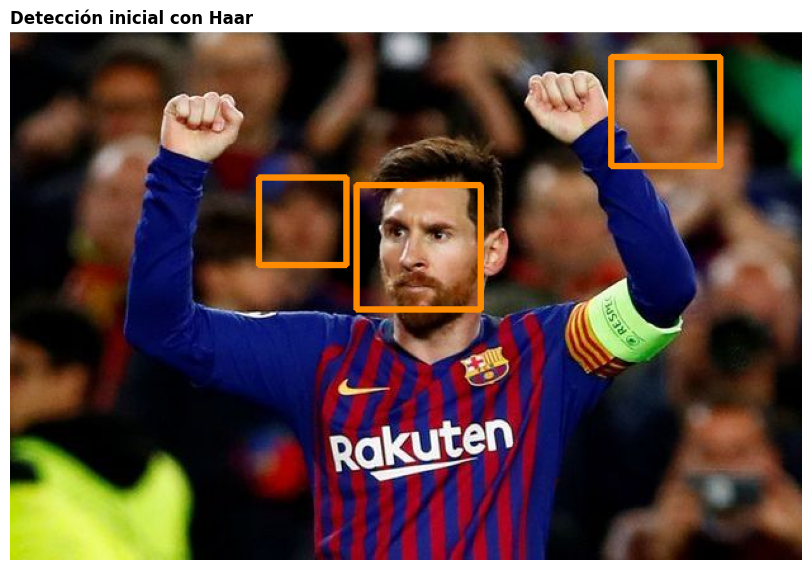

Cantidad de rostros detectados: 3


In [4]:
# Aplicamos el detector con una configuración inicial razonable.
rostros = detector_rostros.detectMultiScale(
    imagen_gris,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(40, 40),
)

# Hacemos una copia de la imagen para dibujar los rectángulos detectados.
imagen_anotada = imagen_rgb.copy()
for x, y, ancho, alto in rostros:
    cv2.rectangle(imagen_anotada, (x, y), (x + ancho, y + alto), (255, 140, 0), 3)

plt.figure(figsize=(8, 6), constrained_layout=True)
plt.imshow(imagen_anotada)
plt.title('Detección inicial con Haar', fontweight='bold', loc='left')
plt.axis('off')
plt.show()

print(f'Cantidad de rostros detectados: {len(rostros)}')


Si la detección funciona, el resultado puede parecer muy directo. Pero conviene no simplificar demasiado la lectura: el detector depende de la escala del rostro, de la iluminación, de la pose y de cuánto se parezca la imagen a los ejemplos con que fue entrenado.


## 3. Comparar una configuración más flexible y una más estricta

Cambiar parámetros puede aumentar detecciones, pero también puede introducir falsos positivos. Vamos a comparar dos configuraciones para ver ese efecto.

- La configuración flexible busca más candidatos.
- La configuración estricta filtra más, pero puede perder detecciones.


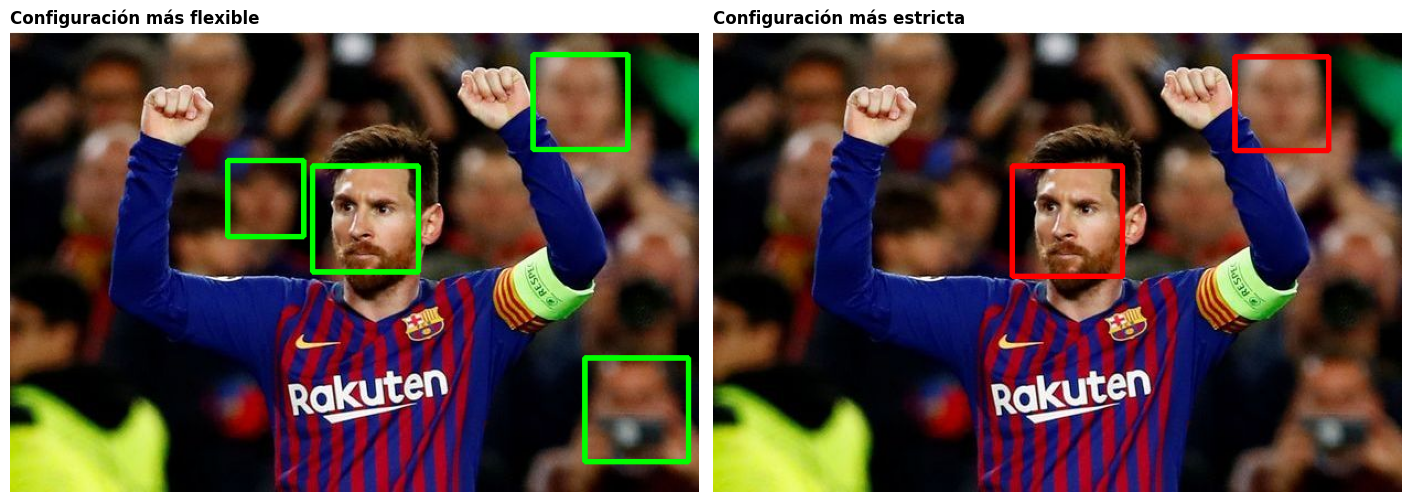

Rostros con configuración flexible: 4
Rostros con configuración estricta: 2


In [6]:
# Configuración más flexible: acepta más regiones como posibles rostros.
rostros_flexibles = detector_rostros.detectMultiScale(
    imagen_gris,
    scaleFactor=1.05,
    minNeighbors=3,
    minSize=(30, 30),
)

# Configuración más estricta: exige más evidencia antes de aceptar una región.
rostros_estrictos = detector_rostros.detectMultiScale(
    imagen_gris,
    scaleFactor=1.2,
    minNeighbors=7,
    minSize=(50, 50),
)

# Dibujamos ambas configuraciones para compararlas visualmente.
imagen_flexible = imagen_rgb.copy()
for x, y, ancho, alto in rostros_flexibles:
    cv2.rectangle(imagen_flexible, (x, y), (x + ancho, y + alto), (0, 255, 0), 3)

imagen_estricta = imagen_rgb.copy()
for x, y, ancho, alto in rostros_estrictos:
    cv2.rectangle(imagen_estricta, (x, y), (x + ancho, y + alto), (255, 0, 0), 3)

fig, ejes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
ejes[0].imshow(imagen_flexible)
ejes[0].set_title('Configuración más flexible', fontweight='bold', loc='left')
ejes[0].axis('off')
ejes[1].imshow(imagen_estricta)
ejes[1].set_title('Configuración más estricta', fontweight='bold', loc='left')
ejes[1].axis('off')
plt.show()

print(f'Rostros con configuración flexible: {len(rostros_flexibles)}')
print(f'Rostros con configuración estricta: {len(rostros_estrictos)}')


Esta comparación deja una lección importante: ajustar un detector no es un detalle cosmético. Cambiar un parámetro puede modificar qué regiones se aceptan, cuáles se rechazan y cuánta confianza nos inspira el resultado final.


## Actividad breve

Modificá `scaleFactor` o `minNeighbors` y volvé a correr el detector. Después explicá:

1. qué cambió en la cantidad de detecciones;
2. si apareció algún falso positivo o si se perdió alguna detección;
3. por qué ajustar un detector no es lo mismo que cambiar un simple valor estético.


## Recurso adicional

Si querés profundizar, podés consultar este texto de referencia:

- [Computer Vision: Algorithms and Applications, 2nd ed.](https://szeliski.org/Book/)


## Cierre

Las cascadas de Haar son un ejemplo clásico de detección automática. Funcionan bien en situaciones relativamente controladas y ayudan a entender una lógica importante: un detector depende tanto del modelo como de la imagen y de los parámetros elegidos. Por eso conviene usarlas críticamente y no como una caja negra infalible.
